In [52]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

import warnings

warnings.filterwarnings("ignore")

# Data load & DataFrame 변환


In [31]:
cdc_data = fetch_ucirepo(id=891).data
features = cdc_data.features
targets = cdc_data.targets

data = pd.concat([features, targets], axis=1)

# 전체 데이터 통계 정리


In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                253680 non-null  int64
 1   HighChol              253680 non-null  int64
 2   CholCheck             253680 non-null  int64
 3   BMI                   253680 non-null  int64
 4   Smoker                253680 non-null  int64
 5   Stroke                253680 non-null  int64
 6   HeartDiseaseorAttack  253680 non-null  int64
 7   PhysActivity          253680 non-null  int64
 8   Fruits                253680 non-null  int64
 9   Veggies               253680 non-null  int64
 10  HvyAlcoholConsump     253680 non-null  int64
 11  AnyHealthcare         253680 non-null  int64
 12  NoDocbcCost           253680 non-null  int64
 13  GenHlth               253680 non-null  int64
 14  MentHlth              253680 non-null  int64
 15  PhysHlth              253680 non-n

In [33]:
data.describe()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,...,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875,0.139333
std,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,...,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148,0.346294
min,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000,0.000000
50%,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000,0.000000
75%,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000,0.000000
max,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000,1.000000


# Unique Value 개수 확인


In [ ]:
unique_values = {}
for col in data.columns:
    unique_values[col] = data[col].value_counts().shape[0]

pd.DataFrame(
    dict(sorted(unique_values.items(), key=lambda x: -x[1])),
    index=["unique value count"],
).transpose()

,unique value count
BMI,84
MentHlth,31
PhysHlth,31
Age,13
Income,8
Education,6
GenHlth,5
HighBP,2
HighChol,2
CholCheck,2


# Column의 value 별 개수 확인


In [45]:
for col in data:
    print(data[col].value_counts(), end="\n\n")
    print("=========", end="\n\n")

HighBP
0    144851
1    108829
Name: count, dtype: int64


HighChol
0    146089
1    107591
Name: count, dtype: int64


CholCheck
1    244210
0      9470
Name: count, dtype: int64


BMI
27    24606
26    20562
24    19550
25    17146
28    16545
      ...  
91        1
85        1
96        1
90        1
78        1
Name: count, Length: 84, dtype: int64


Smoker
0    141257
1    112423
Name: count, dtype: int64


Stroke
0    243388
1     10292
Name: count, dtype: int64


HeartDiseaseorAttack
0    229787
1     23893
Name: count, dtype: int64


PhysActivity
1    191920
0     61760
Name: count, dtype: int64


Fruits
1    160898
0     92782
Name: count, dtype: int64


Veggies
1    205841
0     47839
Name: count, dtype: int64


HvyAlcoholConsump
0    239424
1     14256
Name: count, dtype: int64


AnyHealthcare
1    241263
0     12417
Name: count, dtype: int64


NoDocbcCost
0    232326
1     21354
Name: count, dtype: int64


GenHlth
2    89084
3    75646
1    45299
4    31570
5    12081
Name

# Outlier 확인


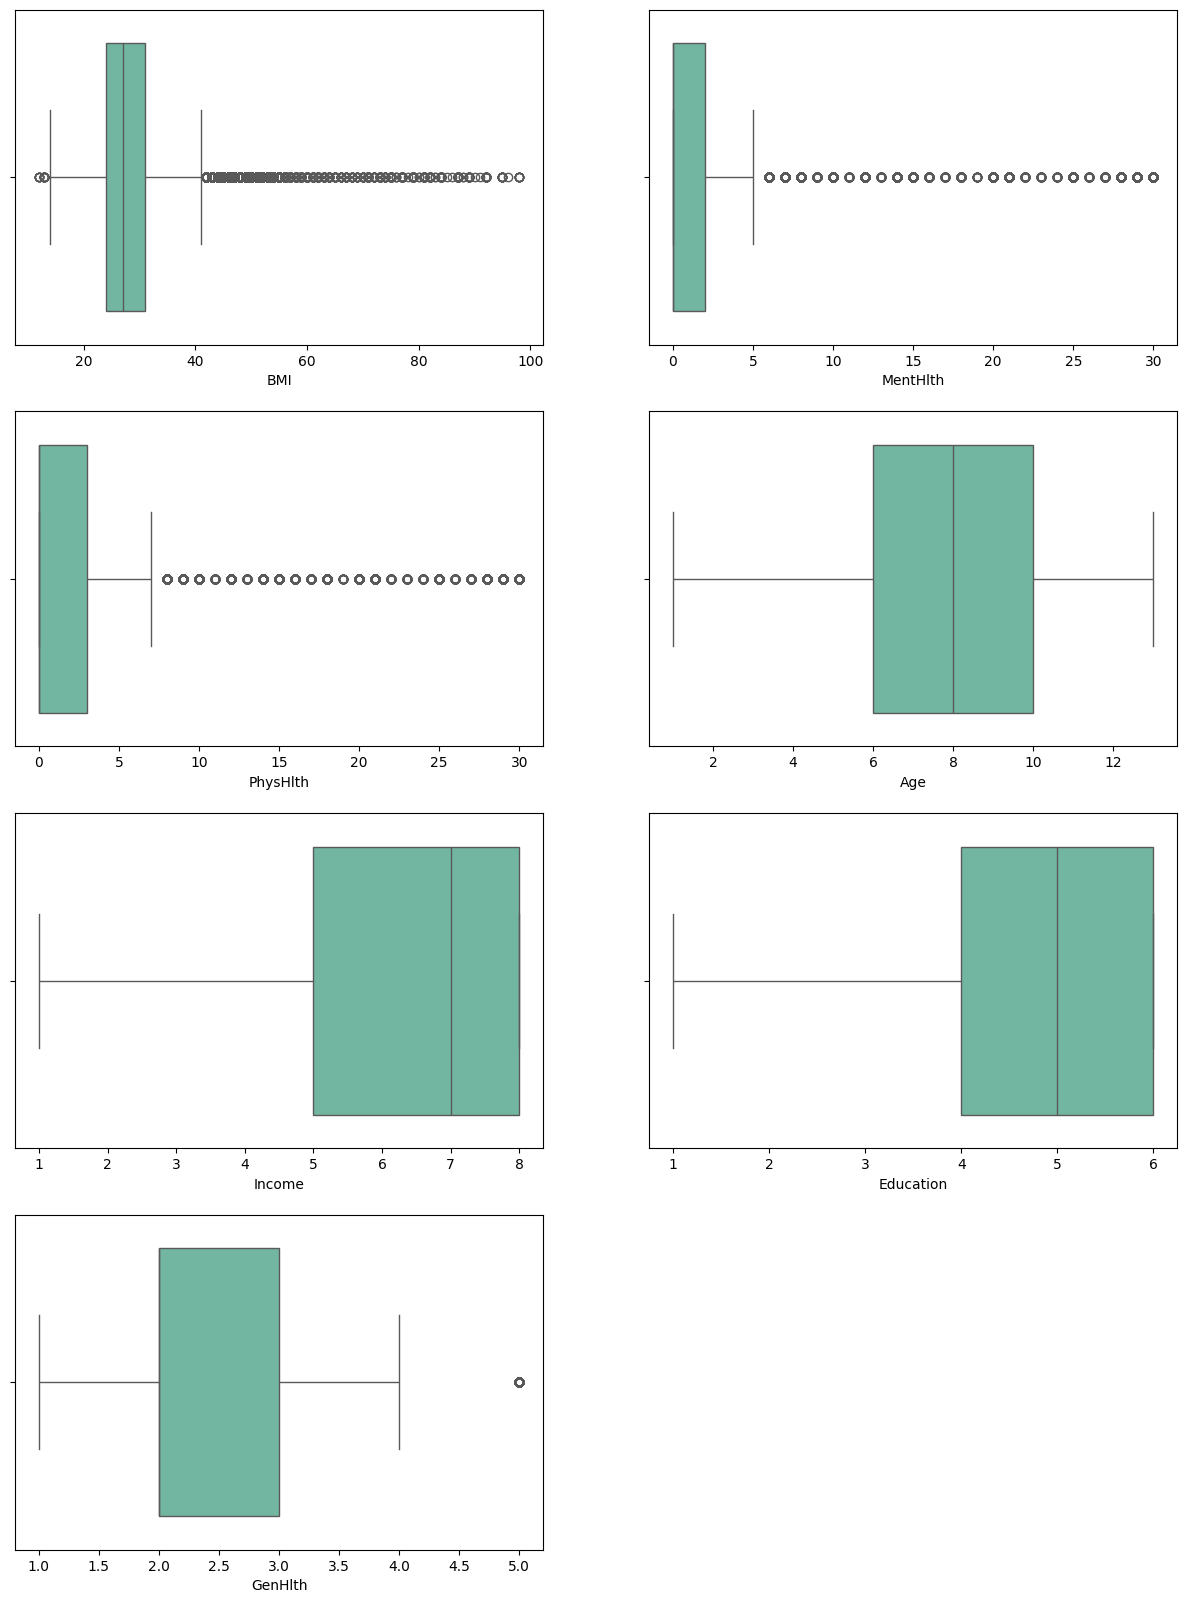

In [ ]:
plt.figure(figsize=(15, 20))

# unique 값이 2개 보다 많은 col에 대해서 outlier 확인
not_binary_cols = [
    "BMI",
    "MentHlth",
    "PhysHlth",
    "Age",
    "Income",
    "Education",
    "GenHlth",
]
for i, col in enumerate(not_binary_cols):
    plt.subplot(4, 2, i + 1)
    sns.boxplot(x=col, data=data, palette="Set2")
plt.show()

# 중복 데이터 확인 및 제거


In [59]:
print(f"중복 데이터 수 -> {data.duplicated().sum()}")
remove_duplicated_data = data.drop_duplicates()
print(f"중복 제거 전 데이터 크기 -> {len(data)}")
print(f"중복 제거 후 데이터 크기 -> {len(remove_duplicated_data)}")

중복 데이터 수 -> 24206
중복 제거 전 데이터 크기 -> 253680
중복 제거 후 데이터 크기 -> 229474


# feature 별 상관관계 파악


Text(0.5, 1.0, 'correlation of feature')

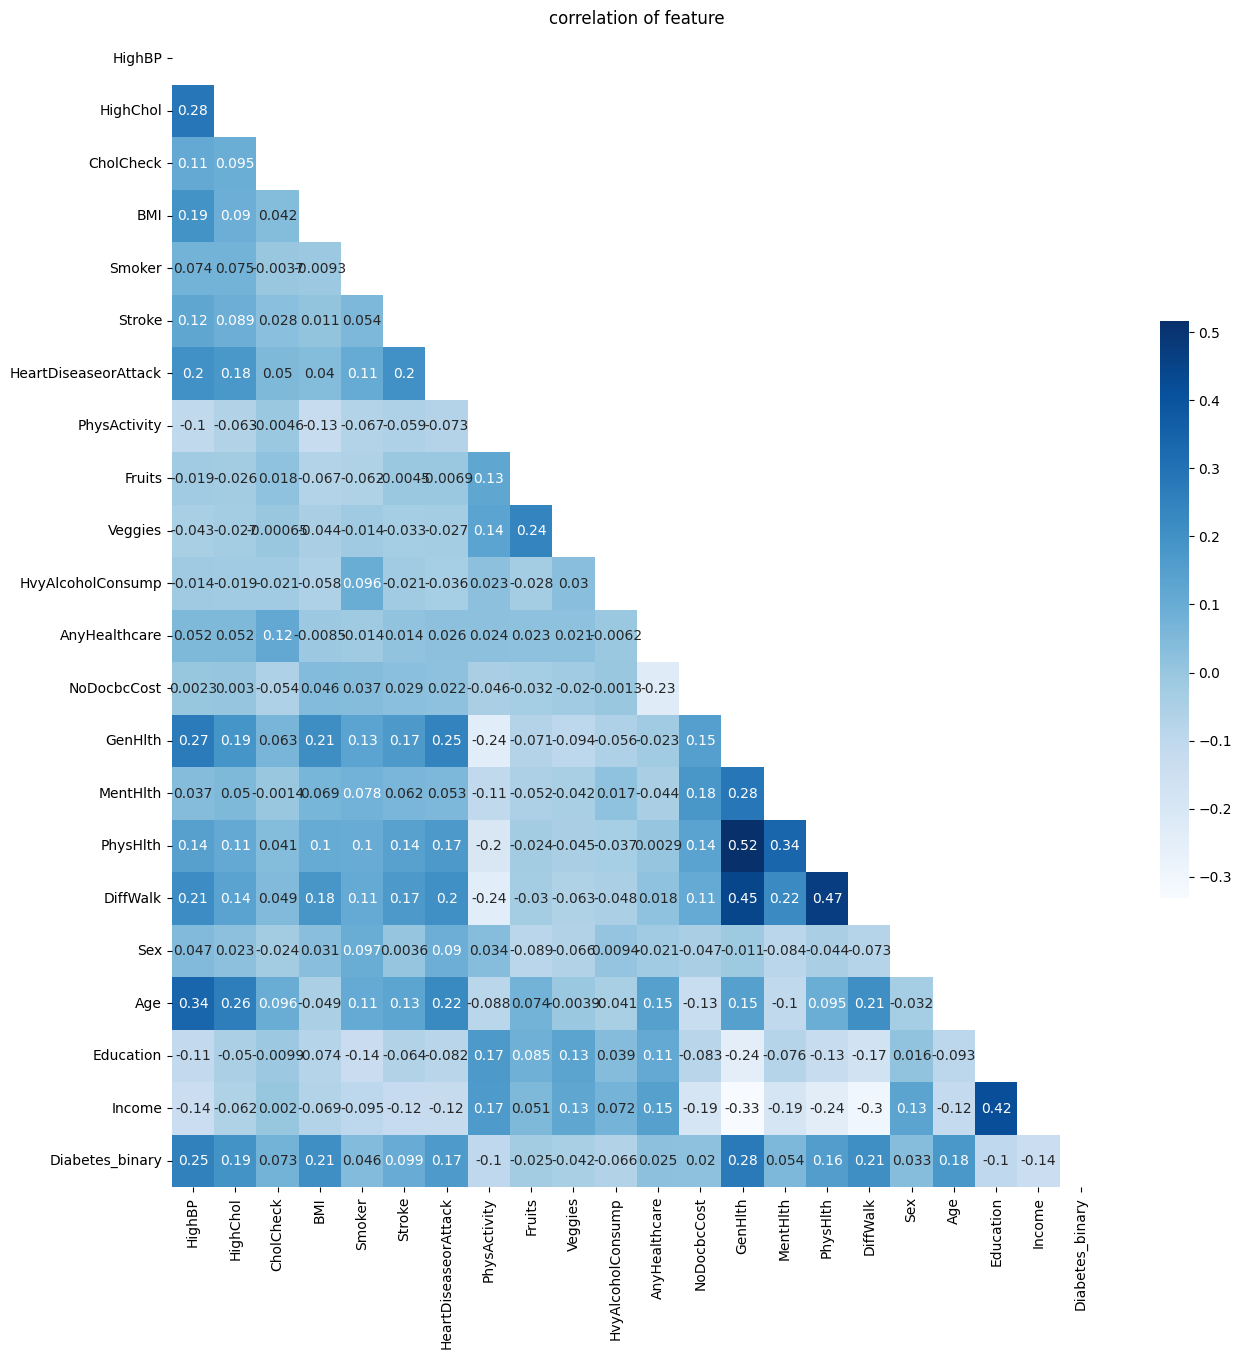

In [74]:
plt.figure(figsize=(15, 15))

corr_data = remove_duplicated_data.corr()

mask = np.zeros_like(corr_data, dtype=np.bool_)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_data, mask=mask, annot=True, cmap="Blues", cbar_kws={"shrink": 0.5})
plt.title("correlation of feature")

# 양의 상관관계
# (GenHlth, PhysHlth)
# (PhysHlth, DiffWalk)
# (GenHlth, DiffWalk)

# 음의 상관관계
# (GenHlth, Income)
# (DiffWalk, Income)

# About Target Value


Diabetes_binary
0    194377
1     35097
Name: count, dtype: int64


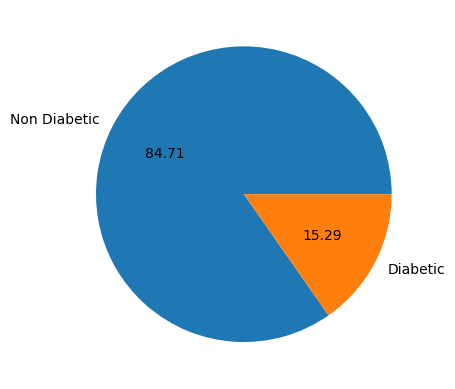

In [81]:
print(remove_duplicated_data["Diabetes_binary"].value_counts())
# 1 -> Diabetes, 0 -> No Diabetes

labels = ["Non Diabetic", "Diabetic"]
plt.pie(
    remove_duplicated_data["Diabetes_binary"].value_counts(),
    labels=labels,
    autopct="%.02f",
)
plt.show()

# 특정 Feature와 Diabetic의 관계


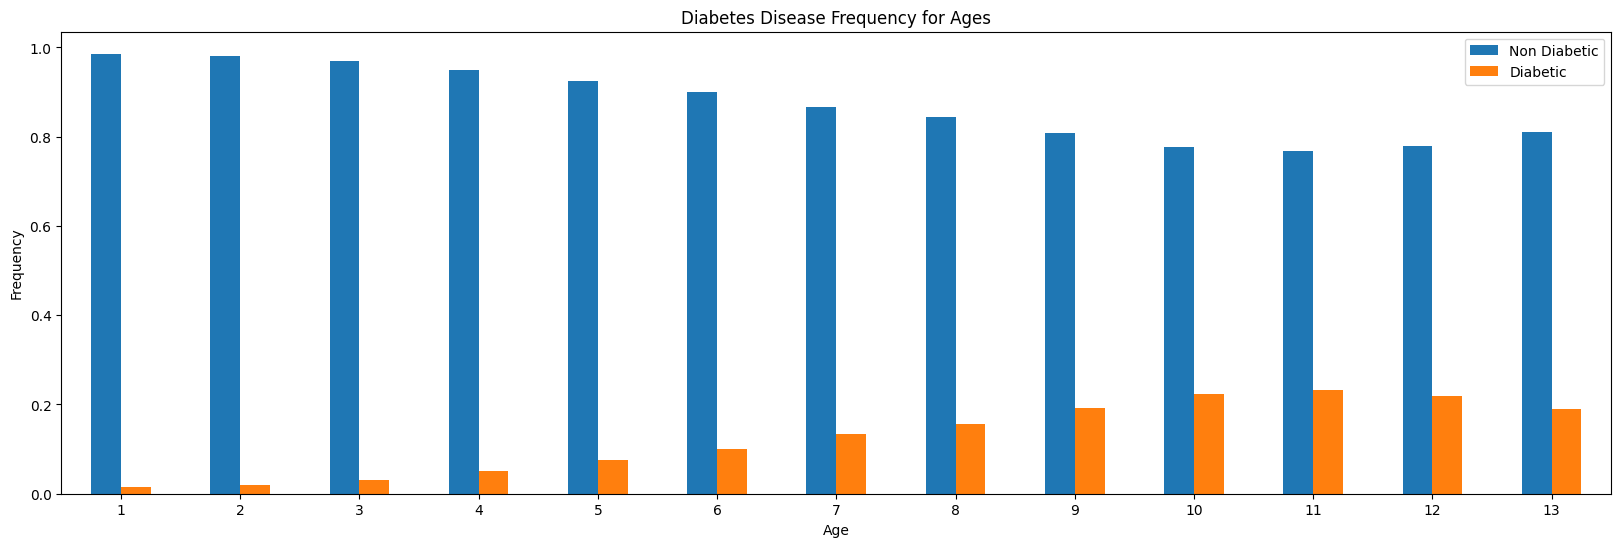

In [90]:
# 나이와 당뇨병의 관계
ct = pd.crosstab(
    remove_duplicated_data["Age"],
    remove_duplicated_data["Diabetes_binary"],
    normalize="index",
)
ct.plot(kind="bar", figsize=(20, 6))
plt.title("Diabetes Disease Frequency for Ages")
plt.xlabel("Age")
plt.xticks(rotation=0)
plt.ylabel("Frequency")
plt.legend(labels)
plt.show()

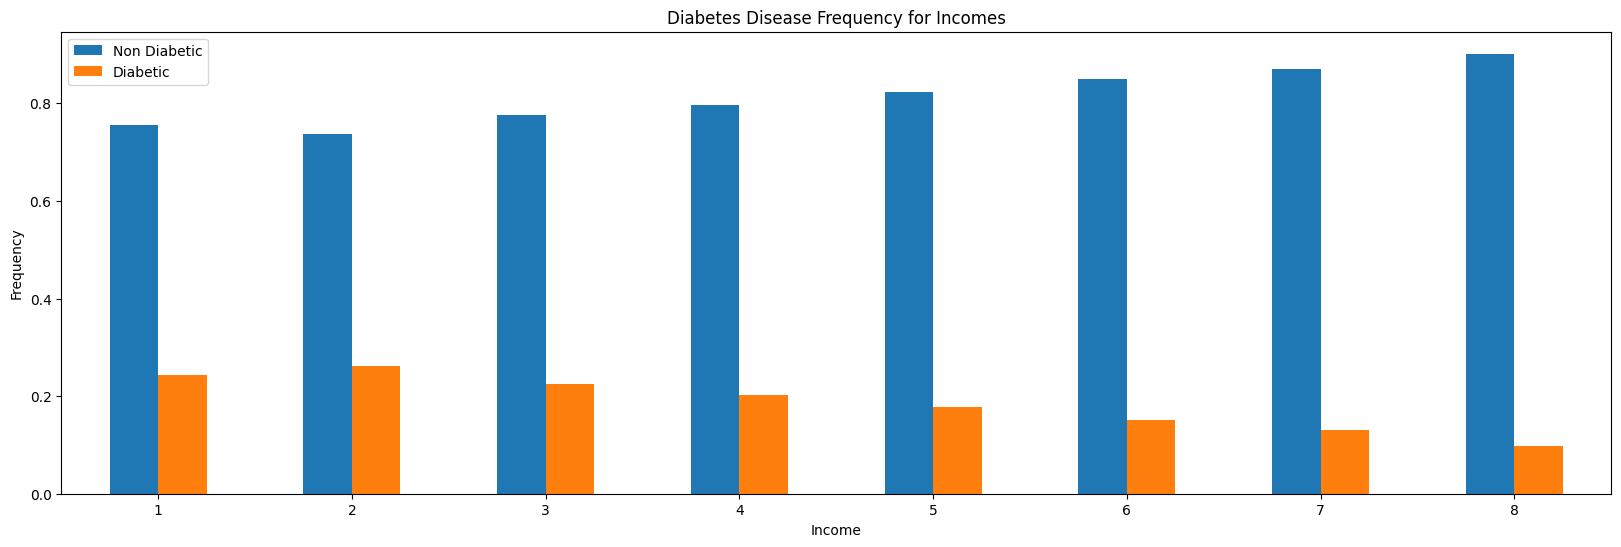

In [88]:
# 수입과 당뇨병의 관계
ct = pd.crosstab(
    remove_duplicated_data["Income"],
    remove_duplicated_data["Diabetes_binary"],
    normalize="index",
)
ct.plot(kind="bar", figsize=(20, 6))
plt.title("Diabetes Disease Frequency for Incomes")
plt.xlabel("Income")
plt.xticks(rotation=0)
plt.ylabel("Frequency")
plt.legend(labels)
plt.show()

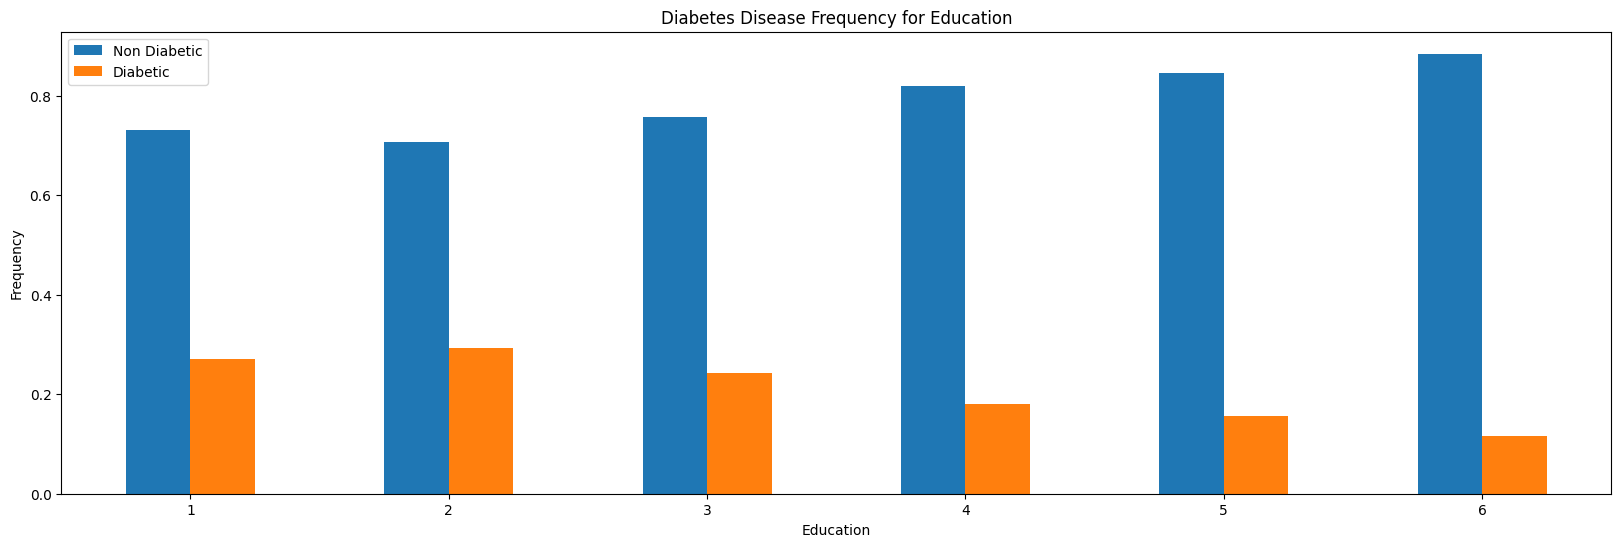

In [ ]:
# 교육과 당뇨병의 관계
ct = pd.crosstab(
    remove_duplicated_data["Education"],
    remove_duplicated_data["Diabetes_binary"],
    normalize="index",
)
ct.plot(kind="bar", figsize=(20, 6))
plt.title("Diabetes Disease Frequency for Education")
plt.xlabel("Education")
plt.xticks(rotation=0)
plt.ylabel("Frequency")
plt.legend(labels)
plt.show()

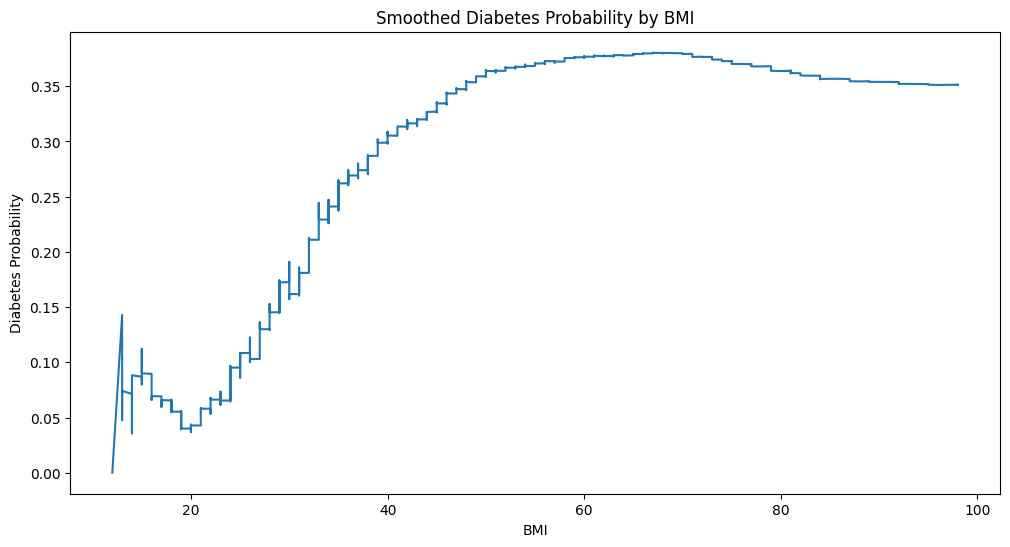

In [ ]:
# BMI 수치와 당뇨병의 관계
tmp = remove_duplicated_data[["BMI", "Diabetes_binary"]].sort_values("BMI")
tmp["rolling_mean"] = tmp["Diabetes_binary"].rolling(5000, min_periods=1).mean()

plt.figure(figsize=(12, 6))
plt.plot(tmp["BMI"], tmp["rolling_mean"])
plt.xlabel("BMI")
plt.ylabel("Diabetes Probability")
plt.title("Smoothed Diabetes Probability by BMI")
plt.show()

# Feature Selection


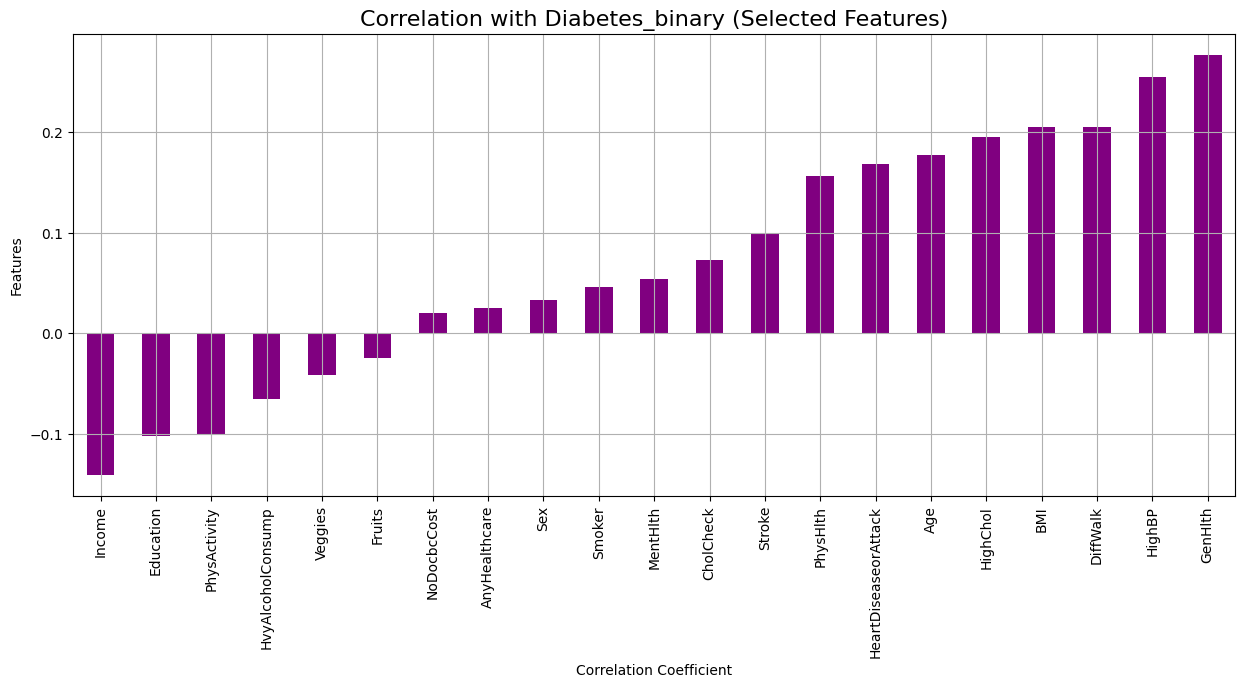

NoDocbcCost             0.020048
Fruits                  0.024805
AnyHealthcare           0.025331
Sex                     0.032724
Veggies                 0.041734
Smoker                  0.045504
MentHlth                0.054153
HvyAlcoholConsump       0.065950
CholCheck               0.072523
Stroke                  0.099193
PhysActivity            0.100404
Education               0.102686
Income                  0.140659
PhysHlth                0.156211
HeartDiseaseorAttack    0.168213
Age                     0.177263
HighChol                0.194944
BMI                     0.205086
DiffWalk                0.205302
HighBP                  0.254318
GenHlth                 0.276940
dtype: float64


In [102]:
with_diabetic_corr = remove_duplicated_data.drop("Diabetes_binary", axis=1).corrwith(
    remove_duplicated_data["Diabetes_binary"]
)

plt.figure(figsize=(15, 6))
with_diabetic_corr.sort_values().plot(kind="bar", color="purple", grid=True)
plt.title("Correlation with Diabetes_binary (Selected Features)", fontsize=16)
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.show()

print(with_diabetic_corr.abs().sort_values())

In [105]:
threshold = 0.04
selected_cols = with_diabetic_corr[with_diabetic_corr.abs() >= threshold].index.tolist()
dropped_cols = with_diabetic_corr[with_diabetic_corr.abs() < threshold].index.tolist()

print("선택된 feature:", selected_cols)
print("제외된 feature:", dropped_cols)

선택된 feature: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Veggies', 'HvyAlcoholConsump', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Age', 'Education', 'Income']
제외된 feature: ['Fruits', 'AnyHealthcare', 'NoDocbcCost', 'Sex']
